# 1. PROJECT TITLE: JIJIYA- AI POWERED MATERNAL AND NEO-NATAL RISK STRATIFICATION TOOL FOR ANTENATAL CARE IN NIGERIAN PRIMARY HEALTH FACILITIES 

The number of maternal deaths in Nigeria per live births account for roughly 20% of global maternal mortality- a rate more than 14 times the SDG 3.1 target of fewer than 70 per 100,000 . Sub-Saharan Africa bore 70% of all global maternal deaths in 2023, and the region is predicted to miss the 2030 target by a factor of 7  at the current trajectory. Direct obsetric causes drive a majority of these deaths, most of which are prevantable by timely identification during routine ANC contacts. 

Heath workers collect ample ANC data, but are not equipped to carry out standardized risk classification. JIJIYA is designed to fill that gap, it takes that data and carries out three-tier risk classification - low, moderate and high. It does not replace the midwife, it equips her.

JIJIYA will deploy a validated, well-equiped, AI-powered decision support tool that will standardise antenatal stratification across Nigerian Health facilities at all levels.

# 2. Methodology

The project will be carried out CRISP-DM methodology, this is one of the more popular data science methodologies and is characterized by six steps

  1. Business Understanding
  2. Data Understanding
  3. Data Preparation
  4. Data Modelling
  5. Model Evaluation
  6. Model Integration and Deployment

# 3. TOOLS
Tools used for this project are:

   1. Pandas
   2. NumPy
   3. matplotlib.plotpy
   4. seaborn
   
   ### 3.1 Pandas
   This is the library imported in projects when working with structured data like excel files, CSV files and SQL files.
   
   ### 3.2 NumPy
   This is the library imported when the project is working with fast mathematical and numerical computations. Pandas is built    on top of NumPy.
   
   ### 3.3 matplotlib.plotpy
   This is the library imported for data visualization (graphs, charts..)
   
   ### 3.4 seaborn
   Built on top of matplotlib library, it is needed to make graphs more efficient and comprehensive.





# 1. Business Understanding

The goal of this project is to improve maternal healthcare by identifying pregnant women who may require urgent clinical 
attention to curb maternal health risk.

The analysis seeks to:

- Understand the characteristics of ANC visits.
- Assess data quality from ANC visits
- Explore relationships between important maternal health indicators.
- Prepare data fo AI-based risk prediction.


# 2. Data Understanding

This is going to use the process of Exploratory Data Analysis (EDA), which is the process of examining data with the goal of extracting insights. These insights allow a better understanding of the available data and what can be done with it.

Just like regular analysis, EDA begins with questions and/or hypotheses, The EDA process will then prove or disprove these hypotheses, and hopefully, reveal other points of inquiry along the way.


In [2]:
#Import all required tools

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme(style="minimal")

ValueError: style must be one of white, dark, whitegrid, darkgrid, ticks

In [5]:
# import the data set

df = pd.read_csv("anc_visits.csv")

df.head()

,visit_id,patient_id,facility_id,visit_number,visit_date,systolic_bp,diastolic_bp,haemoglobin,obstetric_history,gestational_age_weeks,weight_kg,weight_gain_trajectory,presenting_symptoms,bp_machine_available,haemocue_available,recorded_by_device_id
0,38b51c18-4032-443d-8f1c-2e61e4f53d43,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,1,2023-01-10,109.8,84.0,11.9,[],34.2,82.7,NaN,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236
1,7e934575-33a7-4c3e-aa5c-c864f69f2914,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,2,2023-01-25,123.1,84.0,9.8,[],36.3,83.1,0.44,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236
2,2232abd9-32dc-4512-8271-419b784a6c1e,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,3,2023-02-07,132.0,84.0,10.8,[],38.3,84.0,0.84,"[""dysuria""]",True,True,77243d1b-4968-4c66-832b-1bfddd981236
3,8d9f90b1-4df3-47c7-b70e-ae58a1eb908a,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,4,2023-03-02,123.7,84.0,11.8,[],40.7,84.4,0.43,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236
4,29276560-89f8-4870-a826-5565947de07f,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,5,2023-03-07,125.9,84.0,11.1,[],42.7,84.8,0.44,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236


In [6]:
df = pd.read_csv("anc_visits.csv")

df.head()

,visit_id,patient_id,facility_id,visit_number,visit_date,systolic_bp,diastolic_bp,haemoglobin,obstetric_history,gestational_age_weeks,weight_kg,weight_gain_trajectory,presenting_symptoms,bp_machine_available,haemocue_available,recorded_by_device_id
0,38b51c18-4032-443d-8f1c-2e61e4f53d43,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,1,2023-01-10,109.8,84.0,11.9,[],34.2,82.7,NaN,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236
1,7e934575-33a7-4c3e-aa5c-c864f69f2914,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,2,2023-01-25,123.1,84.0,9.8,[],36.3,83.1,0.44,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236
2,2232abd9-32dc-4512-8271-419b784a6c1e,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,3,2023-02-07,132.0,84.0,10.8,[],38.3,84.0,0.84,"[""dysuria""]",True,True,77243d1b-4968-4c66-832b-1bfddd981236
3,8d9f90b1-4df3-47c7-b70e-ae58a1eb908a,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,4,2023-03-02,123.7,84.0,11.8,[],40.7,84.4,0.43,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236
4,29276560-89f8-4870-a826-5565947de07f,fc30c496-2e70-4c9f-8619-087243c2d2b0,96676ddb-b04e-4e7d-b34c-e204a231dd15,5,2023-03-07,125.9,84.0,11.1,[],42.7,84.8,0.44,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236


In [7]:
df.shape

(2224, 16)

This dataset conatains 2224 rows and 16 columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   visit_id                2224 non-null   object 
 1   patient_id              2224 non-null   object 
 2   facility_id             2224 non-null   object 
 3   visit_number            2224 non-null   int64  
 4   visit_date              2224 non-null   object 
 5   systolic_bp             2072 non-null   float64
 6   diastolic_bp            2072 non-null   float64
 7   haemoglobin             1559 non-null   float64
 8   obstetric_history       2224 non-null   object 
 9   gestational_age_weeks   2224 non-null   float64
 10  weight_kg               2224 non-null   float64
 11  weight_gain_trajectory  1824 non-null   float64
 12  presenting_symptoms     2224 non-null   object 
 13  bp_machine_available    2224 non-null   bool   
 14  haemocue_available      2224 non-null   

In [12]:
# feature cardinality
df.nunique()

visit_id                  2224
patient_id                 400
facility_id                  8
visit_number                 8
visit_date                 587
systolic_bp                549
diastolic_bp               329
haemoglobin                101
obstetric_history           37
gestational_age_weeks      335
weight_kg                  505
weight_gain_trajectory     149
presenting_symptoms        146
bp_machine_available         2
haemocue_available           2
recorded_by_device_id        8
dtype: int64

In [9]:
# Check for missing values
df.isnull().sum()

visit_id                    0
patient_id                  0
facility_id                 0
visit_number                0
visit_date                  0
systolic_bp               152
diastolic_bp              152
haemoglobin               665
obstetric_history           0
gestational_age_weeks       0
weight_kg                   0
weight_gain_trajectory    400
presenting_symptoms         0
bp_machine_available        0
haemocue_available          0
recorded_by_device_id       0
dtype: int64

In [10]:
# Check for duplicate rows
df.duplicated().sum()

0

There are no duplicate rows in the dataset

In [11]:
# DATA SUMMARY
df.describe(include='all')

,visit_id,patient_id,facility_id,visit_number,visit_date,systolic_bp,diastolic_bp,haemoglobin,obstetric_history,gestational_age_weeks,weight_kg,weight_gain_trajectory,presenting_symptoms,bp_machine_available,haemocue_available,recorded_by_device_id
count,2224,2224,2224,2224.000000,2224,2072.000000,2072.000000,1559.000000,2224,2224.000000,2224.000000,1824.000000,2224,2224,2224,2224
unique,2224,400,8,NaN,587,NaN,NaN,NaN,37,NaN,NaN,NaN,146,2,2,8
top,38b51c18-4032-443d-8f1c-2e61e4f53d43,7268bc58-a71f-4f29-8bd7-c5ffdb36e323,96676ddb-b04e-4e7d-b34c-e204a231dd15,NaN,2024-02-03,NaN,NaN,NaN,[],NaN,NaN,NaN,[],True,True,77243d1b-4968-4c66-832b-1bfddd981236
freq,1,8,290,NaN,10,NaN,NaN,NaN,1517,NaN,NaN,NaN,1108,2072,1559,290
mean,NaN,NaN,NaN,3.423112,NaN,117.034797,83.966892,11.007697,NaN,28.176844,66.555800,0.520998,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.809762,NaN,17.731398,16.567690,1.762017,NaN,7.498969,11.361218,0.256273,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1.000000,NaN,87.700000,55.000000,3.500000,NaN,8.300000,42.100000,-0.090000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2.000000,NaN,105.800000,75.575000,10.200000,NaN,22.900000,58.500000,0.360000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,3.000000,NaN,112.300000,82.000000,11.300000,NaN,28.100000,66.500000,0.510000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,5.000000,NaN,122.000000,84.000000,12.200000,NaN,33.500000,73.700000,0.650000,NaN,NaN,NaN,NaN


# Data Preparation

This section cleans and prepares the data presented in the data understanding stage

In [12]:
# Convert the visit_date column
df["visit_date"] = pd.to_datetime(df["visit_date"])

In [13]:
# Handle all missing values
df["haemoglobin"] = df["haemoglobin"].fillna(df["haemoglobin"].mode()[0])

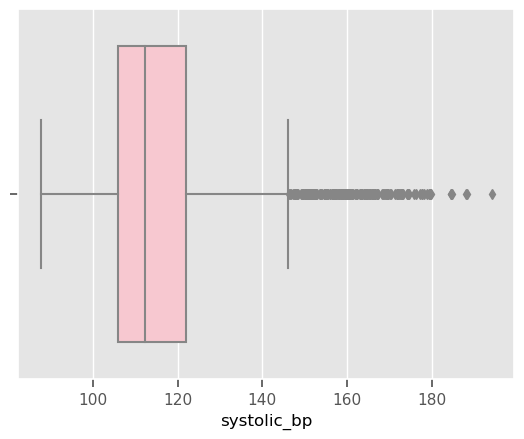

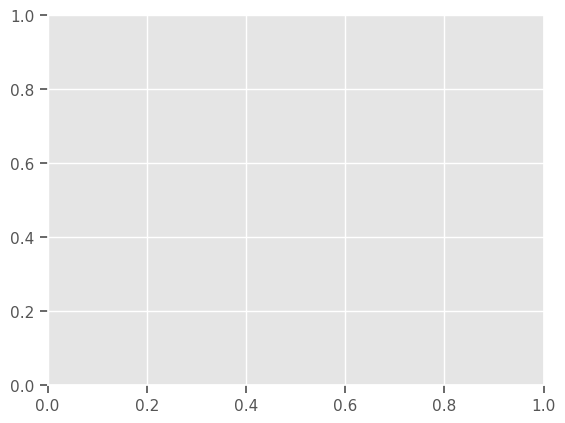

In [14]:
sns.boxplot(x=df["systolic_bp"], color="pink")
plt.show()
plt.grid(True)

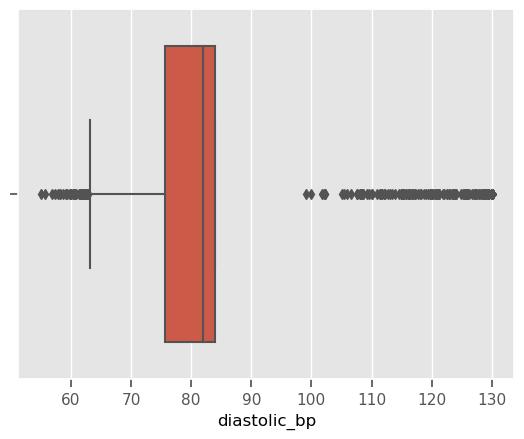

In [15]:
sns.boxplot(x=df["diastolic_bp"])
plt.show()

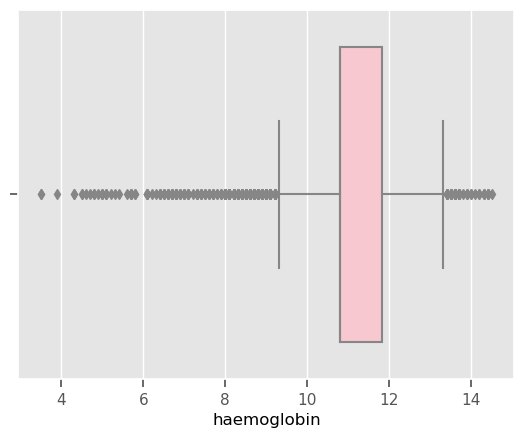

In [16]:
sns.boxplot(x=df["haemoglobin"] ,color="pink")
plt.show()

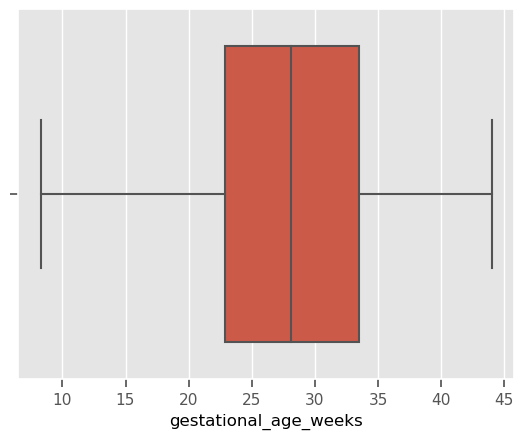

In [17]:
sns.boxplot(x=df["gestational_age_weeks"])
plt.show()

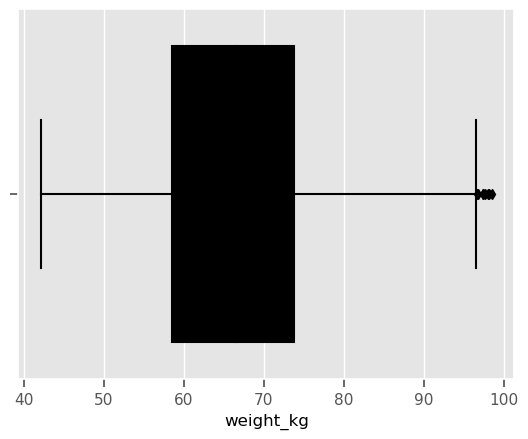

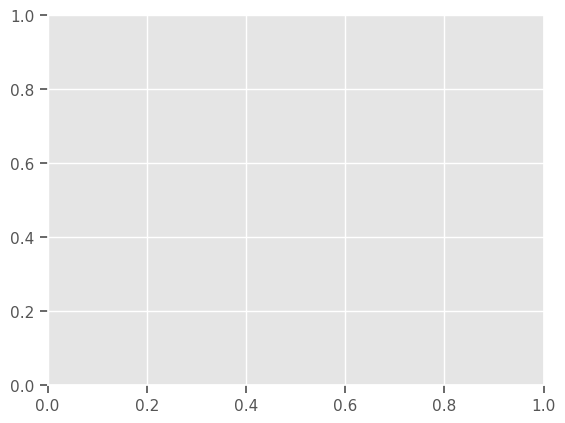

In [18]:
sns.boxplot(x=df["weight_kg"] ,color="black")
plt.show()
plt.grid(True)

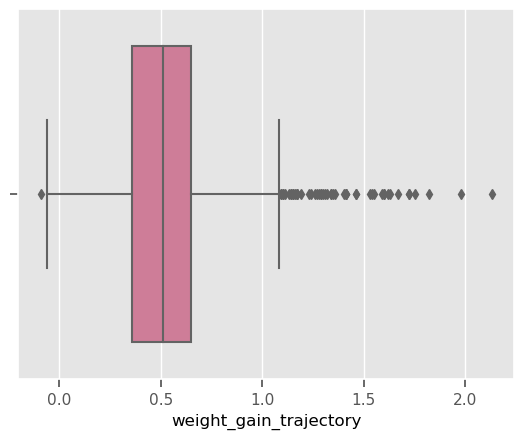

In [19]:
sns.boxplot(x=df["weight_gain_trajectory"] ,color="palevioletred")
plt.show()

# Data modelling

Since there is no machine learning target (it is a stratiffication tool), this section will be focused on Exploratory Data Analysis- a continuation of the previous phase

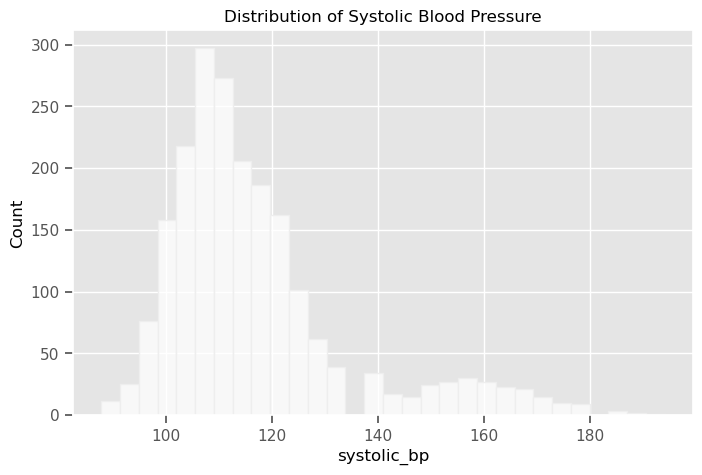

In [22]:
# to plot a histogram for systolic_bp
plt.figure(figsize=(8,5))
sns.histplot(df["systolic_bp"], bins=30 ,color="white")
plt.title("Distribution of Systolic Blood Pressure")
plt.show()

Most women have systolic_bp within the range of 100mmHg-120mmHg, that is normal, systolic_bp from 140mmHg indicates high risk pregnancy

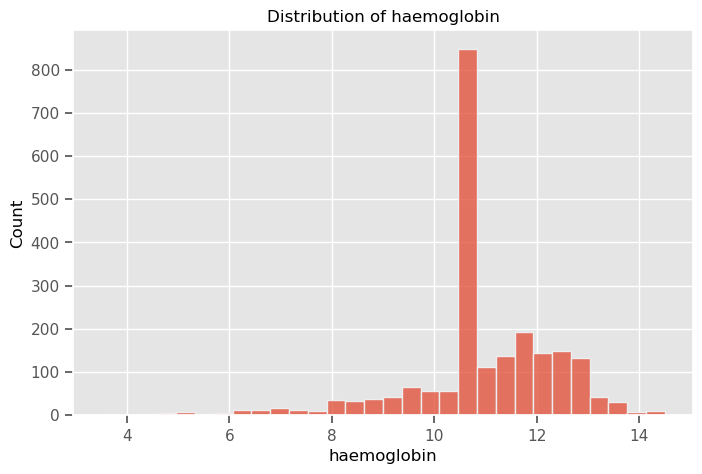

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["haemoglobin"], bins=30)
plt.title("Distribution of haemoglobin")
plt.show()

A few patients have haemoglobin level below the requirement, indicating anaemia, increasing maternal risk.

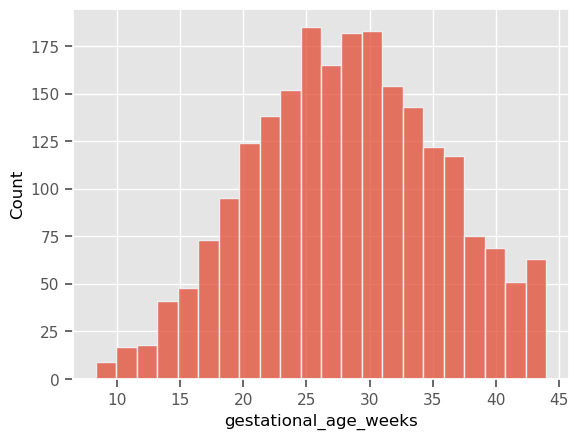

In [24]:
sns.histplot(df["gestational_age_weeks"])
plt.show()

In [ ]:
ANC visits are concentrated during the second trimester, and not in the third and first indicating when most patients seek 
antenatal care.

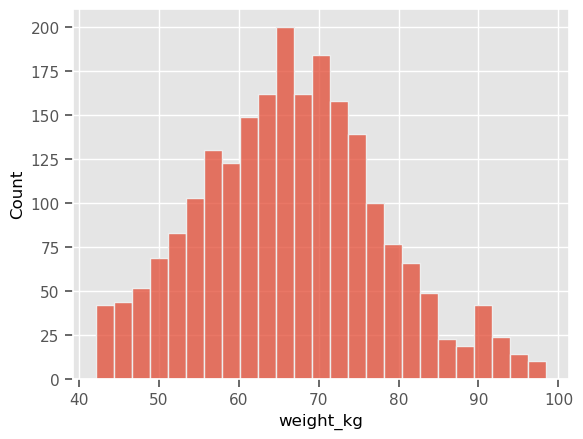

In [25]:
sns.histplot(df["weight_kg"])
plt.show()

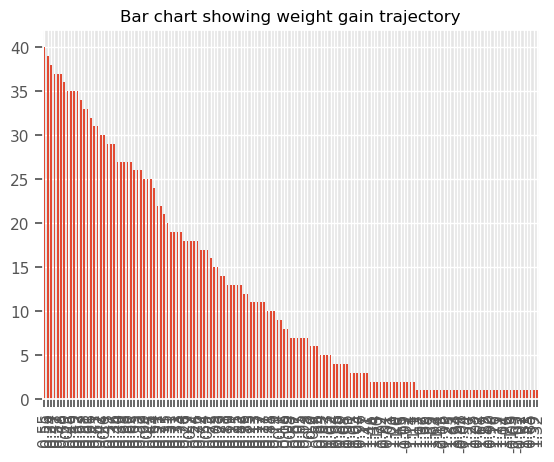

In [27]:
df["weight_gain_trajectory"].value_counts().plot(kind="bar")
plt.title("Bar chart showing weight gain trajectory")
plt.show()

In [28]:
df["presenting_symptoms"].value_counts().head(10)

[]                                      1108
["mild_headache"]                        164
["nausea_vomiting"]                      138
["mild_oedema"]                          136
["vaginal_discharge"]                     92
["fever"]                                 73
["dysuria"]                               48
["shortness_of_breath"]                   28
["mild_headache", "nausea_vomiting"]      28
["mild_headache", "mild_oedema"]          23
Name: presenting_symptoms, dtype: int64

In [29]:
df["obstetric_history"].value_counts()

[]                                                                                                1517
["prior_caesarean_section_uncomplicated"]                                                          107
["prior_anaemia_in_pregnancy"]                                                                     101
["prior_preterm_birth"]                                                                             85
["prior_neonatal_death"]                                                                            60
["eclampsia"]                                                                                       34
["prior_stillbirth"]                                                                                30
["prior_caesarean_section_complicated"]                                                             27
["prior_neonatal_death", "prior_anaemia_in_pregnancy"]                                              23
["prior_caesarean_section_uncomplicated", "prior_caesarean_section_compli

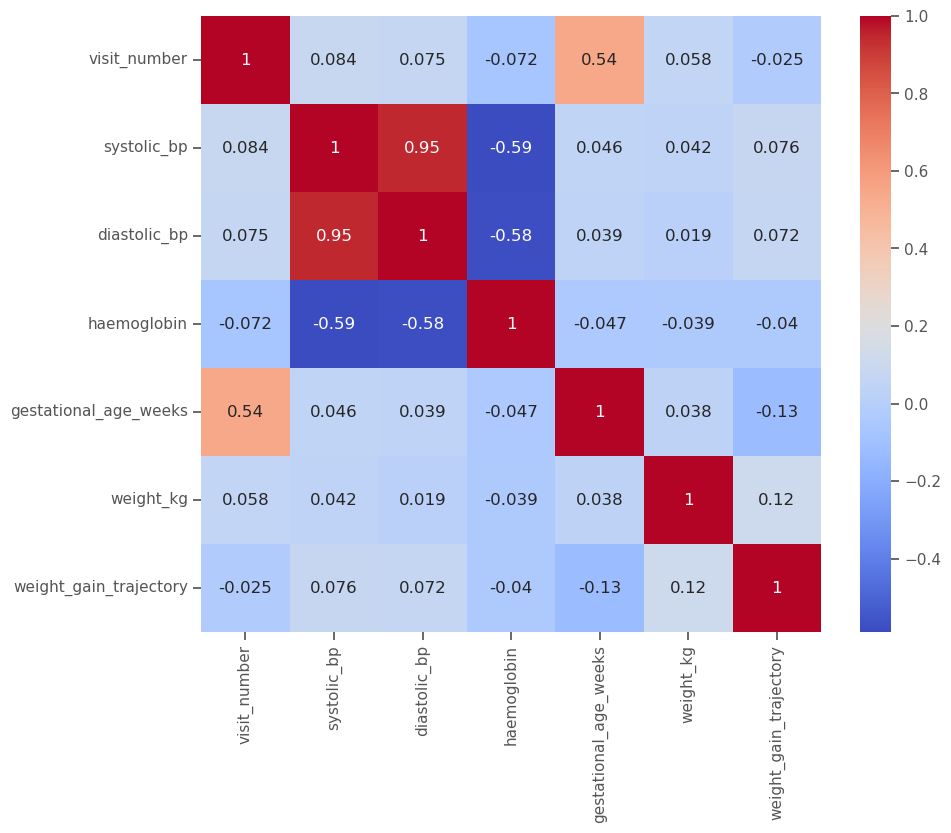

In [30]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
The heatmap shows correlation between every pair of numerical values from all the coloumns.

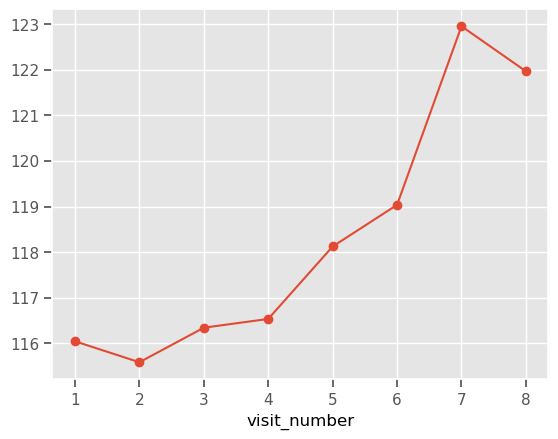

In [31]:
df.groupby("visit_number")["systolic_bp"].mean().plot(marker='o')
plt.show()

Average systolic_bp remained relatively stable across ANC visits, with only slight fluctuations observed over time.

# Evaluation

The exploratory analysis successfully examined the quality and structure of the antenatal care dataset. Numerical variables such as blood pressure, haemoglobin levels, gestational age, and weight were explored for trends and abnormalities. Categorical variables including obstetric history, presenting symptoms, and weight gain trajectory were summarized to understand patient characteristics.

Although no predictive model was developed because the dataset does not include an ml target risk label (Low, Moderate, High), the analysis prepared the data for future machine learning applications. Additional labeled clinical outcomes would be required to train and evaluate a maternal risk prediction model in the future

# Deployment /integration

The cleaned dataset and analytical findings can be integrated into the JIJIYA AI platform. Once a validated risk classification label becomes available, the prepared dataset can be used to train a machine learning model capable of supporting healthcare workers with real-time maternal risk prediction.

Future deployment may include:

- Integration into Streamlit dashboards.
- Deployment through FastAPI.
- Connection to DHIS2 systems.
- Real-time risk prediction within Nigerian Primary Healthcare Centres.